# Correlation: which pre-race features track the finishing position?

Each numeric pre-race feature is measured against the target one at a time — on its own, against the others, and after controlling for the strongest ones.

**The series:** [dataset](dataset.ipynb) → **correlation** → [categorical effects](categorical_effects.ipynb) → [retirements](retirements.ipynb) → [modelling](modelling.ipynb).

Everything comes from `DataFrame.corr()`, **both methods side by side**:

- **Pearson r** — `corr()`. Works on the raw values and measures how close they sit to a *straight line*. It is exactly the R² of a one-feature least squares fit, so it says what a linear model will get from the column as it stands.
- **Spearman ρ** — `corr(method='spearman')`. The same calculation on ranks, so it measures whether the relationship is *consistently increasing*, whatever its shape. Skew and outliers cannot distort it.

Positive means a higher feature value goes with a **worse** finish. `|ρ| - |r|` is the gap between the two: near 0 the relationship is straight, clearly positive means the feature carries order a straight line is failing to use.

Each coefficient carries a 95% confidence interval (Fisher-z) and a p-value (t, on n − 2 degrees of freedom). IDs have no order, so neither applies to them — those are measured with η² in [categorical effects](categorical_effects.ipynb).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from f1_dataset import PRE_RACE, load_dataset
from f1_plots import AXIS, BLUE, ORANGE, SURFACE, corr_heatmap, use_style
from f1_stats import METHODS, correlations, formatted, partial_correlations

use_style()

# how each panel of every side-by-side chart is labelled
TITLES = {'pearson': 'Pearson r — how straight the relationship is',
          'spearman': 'Spearman ρ — how consistent the order is'}

results = load_dataset()
modern = results[results.year >= 2014]
print(f'{len(results):,} starts, {len(modern):,} of them from 2014 on')

25,797 starts, 5,348 of them from 2014 on


## 1. Feature by feature, by era

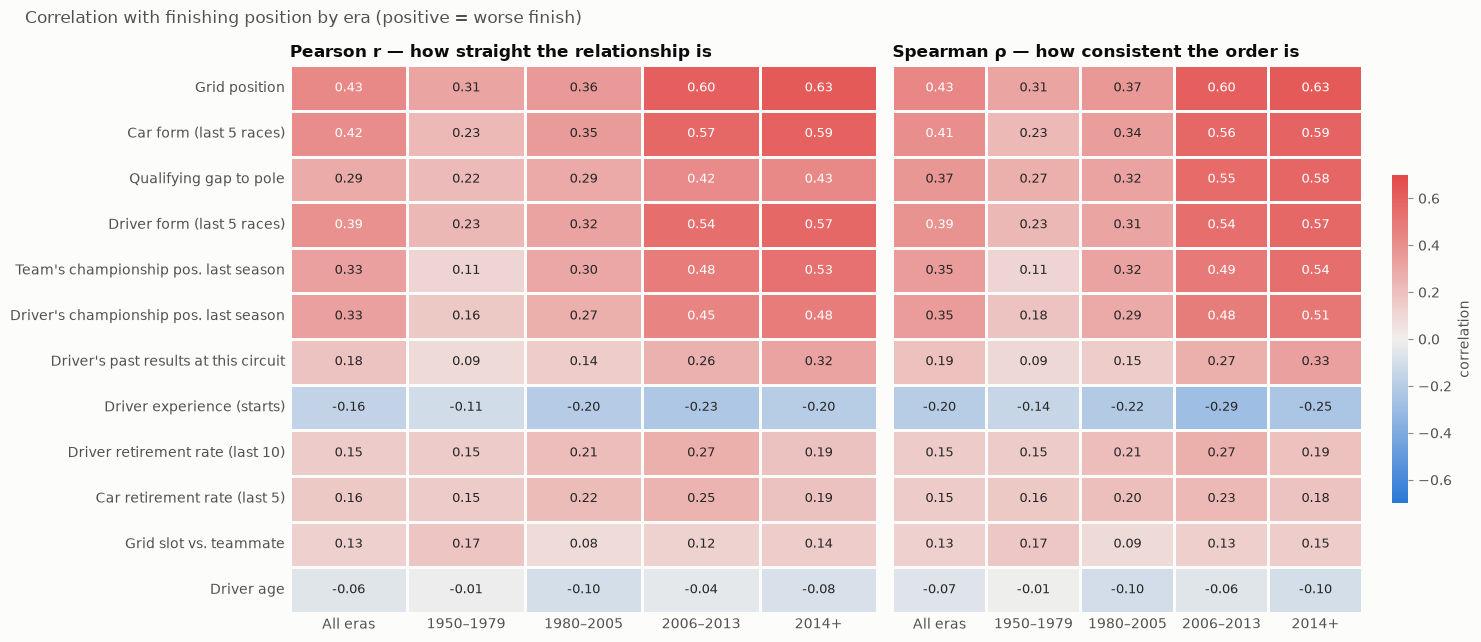

pearson                           \
                                             r ci_low ci_high         p   
Grid position                            0.625  0.608   0.641   0.0e+00   
Car form (last 5 races)                  0.592  0.574   0.609   0.0e+00   
Qualifying gap to pole                   0.429  0.407   0.451  2.4e-235   
Driver form (last 5 races)               0.574  0.556   0.592   0.0e+00   
Team's championship pos. last season     0.529  0.509   0.549   0.0e+00   
Driver's championship pos. last season   0.485  0.462   0.507  1.1e-265   
Driver's past results at this circuit    0.319  0.292   0.345  7.8e-102   
Driver experience (starts)              -0.201 -0.226  -0.175   8.3e-50   
Driver retirement rate (last 10)         0.188  0.161   0.214   1.1e-42   
Car retirement rate (last 5)             0.188  0.162   0.214   1.3e-43   
Grid slot vs. teammate                   0.143  0.117   0.170   2.3e-25   
Driver age                              -0.083 -0.109  -0.056   1.5e-09   

                                       spearman                           \
                                            rho ci_low ci_high         p   
Grid position                             0.628  0.612   0.644   0.0e+00   
Car form (last 5 races)                   0.588  0.570   0.605   0.0e+00   
Qualifying gap to pole                    0.579  0.561   0.597   0.0e+00   
Driver form (last 5 races)                0.569  0.551   0.587   0.0e+00   
Team's championship pos. last season      0.540  0.520   0.560   0.0e+00   
Driver's championship pos. last season    0.507  0.485   0.528  1.5e-294   
Driver's past results at this circuit     0.333  0.306   0.359  2.5e-111   
Driver experience (starts)               -0.246 -0.271  -0.221   1.6e-74   
Driver retirement rate (last 10)          0.192  0.166   0.218   1.1e-44   
Car retirement rate (last 5)              0.183  0.157   0.209   2.3e-41   
Grid slot vs. teammate                    0.145  0.118   0.172   6.4e-26   
Driver age                               -0.104 -0.130  -0.077   2.6e-14   

                                           n |ρ|-|r|  
                                                      
Grid position                           5210   0.003  
Car form (last 5 races)                 5310  -0.004  
Qualifying gap to pole                  5269   0.149  
Driver form (last 5 races)              5266  -0.005  
Team's championship pos. last season    4825   0.011  
Driver's championship pos. last season  4533   0.022  
Driver's past results at this circuit   4289   0.014  
Driver experience (starts)              5348   0.045  
Driver retirement rate (last 10)        5227   0.004  
Car retirement rate (last 5)            5310  -0.005  
Grid slot vs. teammate                  5210   0.002  
Driver age                              5348   0.021

In [2]:
tables = {'All eras': correlations(results, list(PRE_RACE))}
tables.update({era: correlations(g, list(PRE_RACE)) for era, g in results.groupby('era', observed=True)})

panels = {method: pd.DataFrame({era: t[(method, coefficient)] for era, t in tables.items()})
          for method, coefficient in METHODS.items()}
order = panels['spearman']['2014+'].abs().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, method in zip(axes, METHODS):
    corr_heatmap(panels[method].loc[order].rename(index=PRE_RACE), TITLES[method], ax, limit=0.7,
                 cbar=(method == 'spearman'), yticklabels=(method == 'pearson'))
    ax.set_xlabel('')
fig.suptitle('Correlation with finishing position by era (positive = worse finish)', x=0.02, ha='left')
plt.tight_layout()
plt.show()

formatted(correlations(modern, list(PRE_RACE)).loc[order].rename(index=PRE_RACE))

**Reading it**

- Grid position, car form and driver form are the strongest signals on both measures, and last season's championship positions follow closely.
- **The two methods agree on 11 of the 12 features** (`|ρ| - |r|` within ±0.05), so the ranking is not an artefact of the choice. Where they agree, the relationship is close to a straight line and either coefficient will do.
- **Qualifying gap is the exception: r 0.43 against ρ 0.58**, which moves it from third strongest on ρ to sixth on r. The gap is skewed — the median car is ~1.7% off pole while a few backmarkers are 10–20% away — so a straight line fits it badly even though the order is highly informative. That is a fixable shape problem, not a weak feature, and [modelling](modelling.ipynb) fixes it: ranking the gap inside its own race lifts its R² from 0.17 to 0.41. Driver experience is the only other feature to move at all (-0.20 against -0.25).
- The strongest correlation roughly **doubles from the 1950s to the modern era** — 0.31 to 0.63, on either measure. Old results were dominated by mechanical failures, and the fields were far less even. Train on 2006+ or 2014+, or give the model the era as a feature.
- Experience (`drv_starts_before`) is negative: more experienced drivers finish slightly better. Age carries little on its own.
- With about 5,000 modern rows, each confidence interval spans roughly ±0.02, so the ranking above is solid: grid position really does beat car form, and both really beat the driver's circuit history.

## 2. Overlap between features (collinearity)

Two features with the same coefficient against the target are not worth twice as much if they say the same thing. This is the same `corr()`, run between the features themselves instead of against the target.

Both methods fit in one matrix: **below the diagonal is Spearman ρ, above it is Pearson r**. A pair whose two halves differ is a pair where one of the features is skewed.

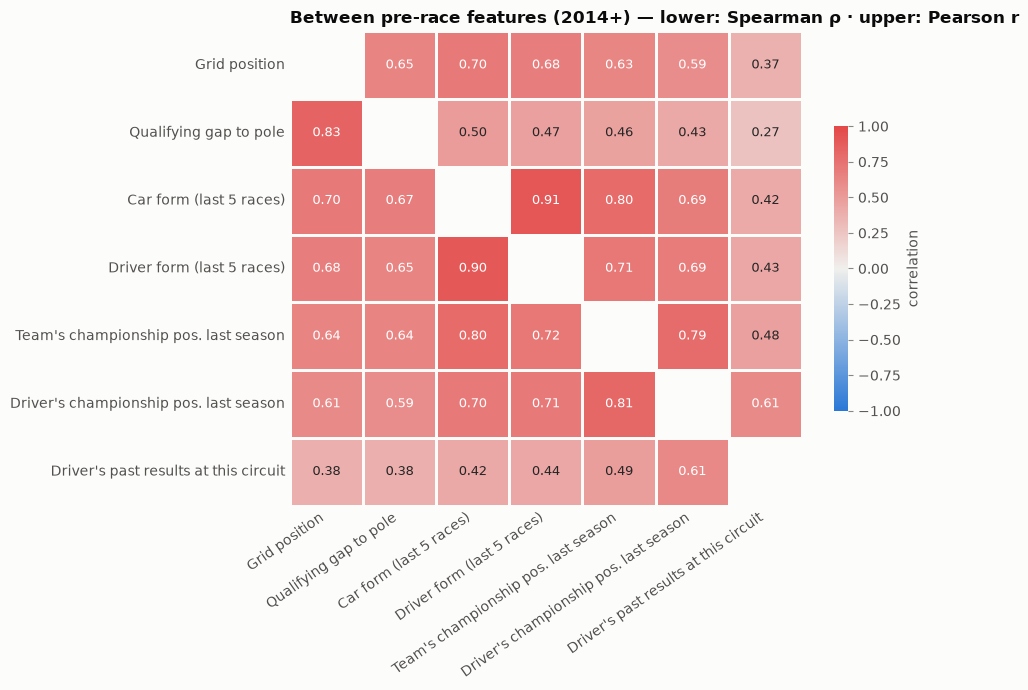

In [3]:
core = ['grid_pct', 'quali_gap_pct', 'con_form5', 'drv_form5', 'con_prev_champ', 'drv_prev_champ', 'drv_circuit_hist']
lower = np.tril(modern[core].corr(method='spearman'), -1)
upper = np.triu(modern[core].corr(), 1)
overlap = pd.DataFrame(lower + upper, index=core, columns=core).rename(index=PRE_RACE, columns=PRE_RACE)

fig, ax = plt.subplots(figsize=(9.5, 7))
corr_heatmap(overlap, 'Between pre-race features (2014+) — lower: Spearman ρ · upper: Pearson r', ax,
             mask=np.eye(len(core), dtype=bool))
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()

**Reading it**

- **Car form and driver form are almost the same signal.** Drivers mostly finish where their car allows, and teammates share a car. To separate them, measure the driver against the teammate (e.g. `teammate_grid_delta`, or finish relative to the car's average).
- Grid position and qualifying gap overlap strongly. Qualifying gap keeps extra information: *how far* apart the cars are, not just their order.
- The qualifying gap is also where the two triangles part company — against every other feature its Pearson half is the weaker one. Same cause as in section 1: the skew, not the signal.

## 3. What does each feature add beyond grid and form?

Partial correlation: the coefficient that remains after removing what **grid position, car form and driver form** already explain. Both columns are regressed on those three and `corr()` is run on what is left over. A feature whose coefficient collapses toward 0 is mostly redundant.

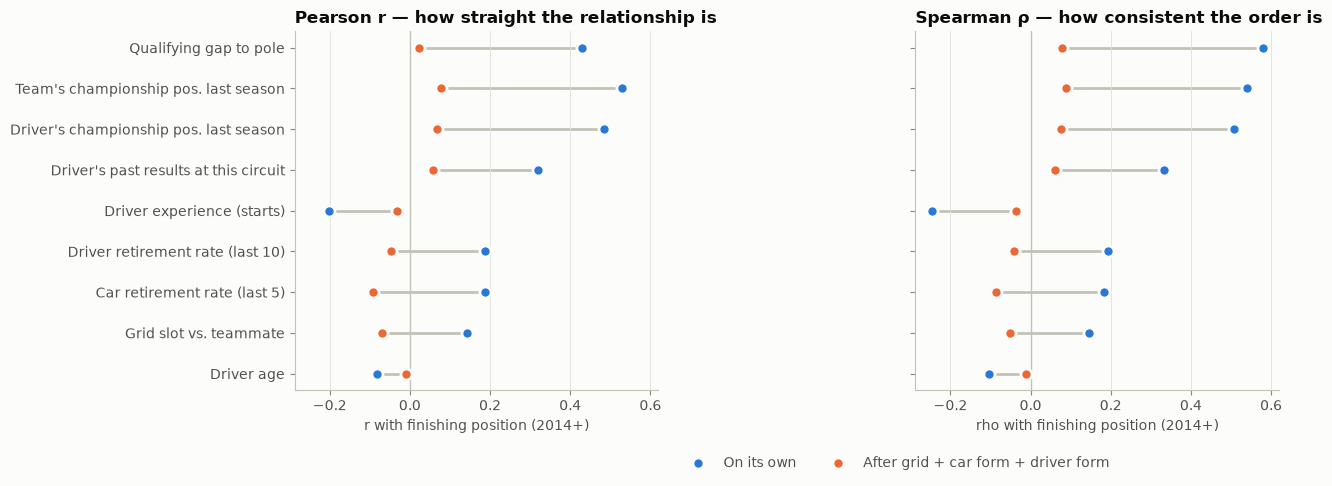

n pearson                           \
                                                   r ci_low ci_high         p   
Driver age                              5348  -0.083 -0.109  -0.056   1.5e-09   
Grid slot vs. teammate                  5210   0.143  0.117   0.170   2.3e-25   
Car retirement rate (last 5)            5310   0.188  0.162   0.214   1.3e-43   
Driver retirement rate (last 10)        5227   0.188  0.161   0.214   1.1e-42   
Driver experience (starts)              5348  -0.201 -0.226  -0.175   8.3e-50   
Driver's past results at this circuit   4289   0.319  0.292   0.345  7.8e-102   
Driver's championship pos. last season  4533   0.485  0.462   0.507  1.1e-265   
Team's championship pos. last season    4825   0.529  0.509   0.549   0.0e+00   
Qualifying gap to pole                  5269   0.429  0.407   0.451  2.4e-235   

                                                           spearman         \
                                       partial_r partial_p      rho ci_low   
Driver age                                -0.009   5.3e-01   -0.104 -0.130   
Grid slot vs. teammate                    -0.069   7.5e-07    0.145  0.118   
Car retirement rate (last 5)              -0.093   2.8e-11    0.183  0.157   
Driver retirement rate (last 10)          -0.048   6.0e-04    0.192  0.166   
Driver experience (starts)                -0.033   2.0e-02   -0.246 -0.271   
Driver's past results at this circuit      0.057   2.3e-04    0.333  0.306   
Driver's championship pos. last season     0.066   1.0e-05    0.507  0.485   
Team's championship pos. last season       0.078   9.0e-08    0.540  0.520   
Qualifying gap to pole                     0.022   1.1e-01    0.579  0.561   

                                                                      \
                                       ci_high         p partial_rho   
Driver age                              -0.077   2.6e-14      -0.012   
Grid slot vs. teammate                   0.172   6.4e-26      -0.052   
Car retirement rate (last 5)             0.209   2.3e-41      -0.087   
Driver retirement rate (last 10)         0.218   1.1e-44      -0.041   
Driver experience (starts)              -0.221   1.6e-74      -0.036   
Driver's past results at this circuit    0.359  2.5e-111       0.060   
Driver's championship pos. last season   0.528  1.5e-294       0.075   
Team's championship pos. last season     0.560   0.0e+00       0.088   
Qualifying gap to pole                   0.597   0.0e+00       0.078   

                                                 |ρ|-|r|  
                                       partial_p          
Driver age                               3.9e-01   0.021  
Grid slot vs. teammate                   2.3e-04   0.002  
Car retirement rate (last 5)             5.2e-10  -0.005  
Driver retirement rate (last 10)         3.3e-03   0.004  
Driver experience (starts)               1.0e-02   0.045  
Driver's past results at this circuit    1.1e-04   0.014  
Driver's championship pos. last season   5.8e-07   0.022  
Team's championship pos. last season     2.3e-09   0.011  
Qualifying gap to pole                   3.4e-08   0.149

In [4]:
controls = ['grid_pct', 'con_form5', 'drv_form5']
others = [c for c in PRE_RACE if c not in controls]
added = (correlations(modern, others).join(partial_correlations(modern, others, controls))
         .sort_index(axis=1, level=0, sort_remaining=False))  # keep each method's columns together
added = added.loc[added[('spearman', 'rho')].abs().sort_values().index]

y = np.arange(len(added))
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, (method, coefficient) in zip(axes, METHODS.items()):
    alone, partial = added[(method, coefficient)], added[(method, f'partial_{coefficient}')]
    ax.hlines(y, partial, alone, color=AXIS, linewidth=2, zorder=1)
    ax.scatter(alone, y, s=64, color=BLUE, edgecolor=SURFACE, linewidth=2, label='On its own', zorder=2)
    ax.scatter(partial, y, s=64, color=ORANGE, edgecolor=SURFACE, linewidth=2,
               label='After grid + car form + driver form', zorder=3)
    ax.axvline(0, color=AXIS, linewidth=1)
    ax.grid(axis='y', visible=False)
    ax.set_title(TITLES[method])
    ax.set_xlabel(f'{coefficient} with finishing position (2014+)')
axes[0].set_yticks(y, added.index.map(PRE_RACE))
axes[1].legend(loc='upper center', bbox_to_anchor=(-0.05, -0.15), ncol=2)
plt.tight_layout()
plt.show()

formatted(added.rename(index=PRE_RACE))

**Reading it**

- Once grid and form are known, every other feature keeps only a small amount of signal. A model can still use these extras, but don't expect a big jump from any single one.
- Most of them stay statistically significant on both measures. **Driver age** does not (p ≈ 0.39 and 0.53). Careful before dropping it: this only rules out a *straight-line* effect once the controls are in, and the boosted model in [modelling](modelling.ipynb) still finds a small non-linear one.
- **Qualifying gap is the clearest split between the two methods**: ρ keeps 0.08 (p ≈ 3e-08) while r keeps 0.02 and stops being significant (p ≈ 0.11). Read together they say the gap still carries usable *order* beyond grid and form, but nothing a straight line can pick up — which is precisely the argument for the rank-within-race transform in [modelling](modelling.ipynb).
- **Retirement rates flip sign.** Recent form counts retirements as bad finishes, so a fast but unreliable car looks worse than its real pace. Controlling for form, a high retirement rate points to a car whose pace is *better* than its form shows. Keep pace and reliability as separate features (e.g. form computed from classified finishes only, plus a retirement rate) — [retirements](retirements.ipynb) takes that apart.

Next: [categorical effects](categorical_effects.ipynb) — the inputs that have no order, so no coefficient.